# 07 — Model Comparison and Commercial Appraisal

The three model families are complete. This notebook answers the research questions from the
results they saved, and applies one discipline consistently: **a difference smaller than the
fold-to-fold variation is not a difference.**

## Nothing is refitted here

Every number is read from `reports/results/`. That is partly forced — PyTorch and XGBoost
cannot share a process — but it is also the more honest procedure. The figures compared are
exactly the ones each notebook reported, with no possibility of a silently different
configuration producing a more convenient answer.

This notebook imports neither `xgboost` nor `torch`.

## What may and may not be compared

The three families do not predict the same thing, and treating their errors as interchangeable
would be the easiest way to reach a wrong conclusion:

| Family | Predicts | Rows behind a fold |
|---|---|---|
| XGBoost | one itinerary at one search date | ~385k–742k |
| LSTM | the same, as a per-flight sequence | ~21k–39k flights |
| SARIMA | the **daily mean fare per route** | 104–160 days |

RMSE on a daily mean is not RMSE on an individual fare — averaging removes most of the
variance, so the daily figures are smaller for reasons unrelated to model quality.
Comparisons are therefore made **within** a granularity. Notebook 05 evaluated persistence and
XGBoost on the daily series precisely so that SARIMA would have like-for-like opponents.

## The test applied to every claim

Because all models saw identical folds, their scores are **paired**. Each comparison reports
the mean difference, how many folds each model won, and a paired *t*-test. With five folds
that test has little power: it can confirm a large consistent difference, but **"within fold
noise" means not shown to differ, never shown to be equal.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flightprice.config import PROJECT_ROOT
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.evaluation.comparison import (
    paired_comparison, comparison_table, confusion_from_metrics, expected_cost,
)

set_plot_style()
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

RESULTS = PROJECT_ROOT / "reports" / "results"
xgb_reg = pd.read_csv(RESULTS / "04_xgboost_regression.csv")
xgb_clf = pd.read_csv(RESULTS / "04_xgboost_classification.csv")
daily = pd.read_csv(RESULTS / "05_sarima_daily.csv")
lstm = pd.read_csv(RESULTS / "06_lstm_results.csv")
importance = pd.read_csv(RESULTS / "04_xgboost_feature_importance.csv", index_col=0)

print(f"loaded {len(xgb_reg) + len(xgb_clf) + len(daily) + len(lstm)} result rows "
      f"from {len(list(RESULTS.glob('*.csv')))} files")

loaded 145 result rows from 8 files


In [2]:
# Two small helpers used throughout this notebook.
#
# Both do the same essential job: pull out one model's score for each round,
# LABELLED BY ROUND. The labelling is the important part -- it guarantees that
# when two models are compared, round 1 is set against round 1 and not against
# round 3. That pairing is what the statistical test relies on.
#
# The daily version is indexed by route AND round, because SARIMA was run on
# four routes separately, giving 4 x 5 = 20 paired comparisons instead of 5.
def fold_scores(frame, metric, **filters):
    """Per-fold scores for one model, indexed by fold so pairs align."""
    sub = frame.copy()
    for column, value in filters.items():
        sub = sub[sub[column] == value]
    return sub.set_index("fold")[metric].sort_index()


def daily_scores(metric, model):
    """Daily-granularity scores indexed by (route, fold) -- 20 paired cells."""
    sub = daily[daily.model == model]
    return sub.set_index(["route", "fold"])[metric].sort_index()

## 1. Research question 1 — how well can fares be predicted?

### 1a. Per-observation granularity

In [3]:
rq1_obs = pd.DataFrame({
    "XGBoost": {
        "RMSE": fold_scores(xgb_reg, "rmse", model="xgboost").mean(),
        "MAE": fold_scores(xgb_reg, "mae", model="xgboost").mean(),
        "R2": fold_scores(xgb_reg, "r2", model="xgboost").mean()},
    "LSTM": {
        "RMSE": fold_scores(lstm, "rmse", task="regression", route_type="long-haul").mean(),
        "MAE": fold_scores(lstm, "mae", task="regression", route_type="long-haul").mean(),
        "R2": fold_scores(lstm, "r2", task="regression", route_type="long-haul").mean()},
    "persistence": {
        "RMSE": fold_scores(xgb_reg, "rmse", model="persistence").mean(),
        "MAE": fold_scores(xgb_reg, "mae", model="persistence").mean(),
        "R2": fold_scores(xgb_reg, "r2", model="persistence").mean()},
}).round(2)
print("Long-haul, mean over 5 folds:")
rq1_obs

Long-haul, mean over 5 folds:


,XGBoost,LSTM,persistence
RMSE,46.99,48.07,50.44
MAE,27.89,29.61,22.46
R2,0.92,0.92,0.90


In [4]:
# Every fare-prediction comparison, run through the same paired test.
#
# Six comparisons: XGBoost vs LSTM, XGBoost vs the naive baseline, and LSTM vs
# the naive baseline -- each judged on both RMSE and MAE.
#
# Reporting both error measures is deliberate and it is where the project's
# most-quoted finding comes from: XGBoost beats the naive baseline on RMSE and
# loses to it on MAE. Had we reported RMSE alone, the write-up would have
# claimed a clean win that the data does not support.
obs_tests = [
    paired_comparison(fold_scores(xgb_reg, m, model="xgboost"),
                      fold_scores(lstm, m, task="regression", route_type="long-haul"),
                      m, "XGBoost", "LSTM") for m in ("rmse", "mae")
] + [
    paired_comparison(fold_scores(xgb_reg, m, model="xgboost"),
                      fold_scores(xgb_reg, m, model="persistence"),
                      m, "XGBoost", "persistence") for m in ("rmse", "mae")
] + [
    paired_comparison(fold_scores(lstm, m, task="regression", route_type="long-haul"),
                      fold_scores(xgb_reg, m, model="persistence"),
                      m, "LSTM", "persistence") for m in ("rmse", "mae")
]
comparison_table(obs_tests)

,metric,model A,model B,mean A,mean B,difference,A wins,sd of diffs,p,better,verdict
0,mae,LSTM,persistence,29.6142,22.4635,7.1507,0/5,4.3765,0.0217,persistence,distinguishable
1,mae,XGBoost,persistence,27.8862,22.4635,5.4227,0/5,6.4004,0.1311,—,within fold noise
2,rmse,XGBoost,persistence,46.9858,50.4422,-3.4564,4/5,5.4272,0.2275,—,within fold noise
3,rmse,LSTM,persistence,48.0663,50.4422,-2.3759,4/5,4.0022,0.2551,—,within fold noise
4,mae,XGBoost,LSTM,27.8862,29.6142,-1.7280,4/5,3.7603,0.3622,—,within fold noise
5,rmse,XGBoost,LSTM,46.9858,48.0663,-1.0805,4/5,4.5416,0.6229,—,within fold noise


Three things follow, and only one of them is a clean win.

**XGBoost and the LSTM are not distinguishable on fare prediction.** Neither RMSE nor MAE
separates them (p = 0.62 and 0.36). The answer to "which model predicts fares better" is *not
established* — a legitimate finding, and more defensible than ranking on a difference of about
2%.

**Against persistence, neither direction reaches significance on long-haul alone** — RMSE
p = 0.23, MAE p = 0.13. That is a power problem rather than an absence of effect: five paired
folds is very little to work with, and the MAE difference is perfectly consistent in direction
(persistence wins 5 of 5) while varying in size, which a *t*-test penalises.

Both route types were run under the identical protocol, so pooling them tests the same
hypothesis with ten paired cells instead of five.

### 1b. Daily granularity

Here SARIMA can compete, on a target it can actually model. Cells are (route, fold) pairs, so
each comparison rests on 20 paired observations rather than 5.

In [5]:
# Long-haul alone gives five paired folds, which is very little power. Both
# route types were evaluated under the identical protocol, so pooling them gives
# ten paired cells and a fairer test of the same hypothesis.
def pooled_scores(model_long, model_short, metric):
    return pd.concat([
        xgb_reg[xgb_reg.model == model_long].assign(cell=lambda d: "long-" + d.fold.astype(str)),
        xgb_reg[xgb_reg.model == model_short].assign(cell=lambda d: "short-" + d.fold.astype(str)),
    ]).set_index("cell")[metric].sort_index()

pooled_tests = [
    paired_comparison(pooled_scores("xgboost", "short-haul: xgboost", m),
                      pooled_scores("persistence", "short-haul: persistence", m),
                      m, "XGBoost (both routes)", "persistence (both routes)")
    for m in ("rmse", "mae")
]
comparison_table(pooled_tests)

,metric,model A,model B,mean A,mean B,difference,A wins,sd of diffs,p,better,verdict
0,rmse,XGBoost (both routes),persistence (both routes),34.4127,38.4389,-4.0262,9/10,3.8477,0.0091,XGBoost (both routes),distinguishable
1,mae,XGBoost (both routes),persistence (both routes),19.7474,16.2348,3.5127,0/10,4.7903,0.0456,persistence (both routes),distinguishable


Pooled, **the split decision is real**: XGBoost is better on RMSE (9 of 10 cells, p = 0.009)
and persistence is better on MAE (**0 of 10** — XGBoost never wins a single fold, p = 0.046).

The cause is the step-function structure established in notebook 02. Fares repeat exactly 62%
of the time, so "no change" is often precisely right, which MAE rewards; what persistence
cannot do is anticipate a jump, and when one arrives it is wrong by the whole step, which is
what RMSE punishes.

**Reporting RMSE alone — as the closest precedent in the literature does — would have shown
XGBoost comfortably ahead and concealed that a naive forecast predicts the typical fare more
accurately.** That is the substantive methodological point of this section.

It is also a useful illustration of the test's limits. The same effect was invisible at five
folds and clear at ten. "Within fold noise" genuinely means *not shown*, and a study with more
folds might separate several of the comparisons that fail below.

In [6]:
rq1_daily = (daily.groupby("model")[["rmse", "mae", "r2"]]
             .agg(["mean", "median"]).round(2))
print("Daily mean fare, over 4 routes x 5 folds:")
rq1_daily

Daily mean fare, over 4 routes x 5 folds:


rmse           mae           r2       
                  mean median   mean median  mean median
model                                                   
persistence      44.00  40.24  33.83  30.33 -0.30  -0.49
sarima           25.06  19.40  19.61  15.74  0.53   0.64
sarimax          29.27  19.89  22.29  15.42  0.27   0.64
xgboost (daily)  35.24  29.86  29.24  22.68  0.10   0.38

In [7]:
daily_tests = []
for metric in ("rmse", "mae"):
    for other in ("xgboost (daily)", "persistence", "sarimax"):
        daily_tests.append(paired_comparison(
            daily_scores(metric, "sarima"), daily_scores(metric, other),
            metric, "SARIMA", other))
comparison_table(daily_tests)

,metric,model A,model B,mean A,mean B,difference,A wins,sd of diffs,p,better,verdict
0,rmse,SARIMA,persistence,25.0640,43.9963,-18.9323,18/20,16.1539,0.0000,SARIMA,distinguishable
1,mae,SARIMA,persistence,19.6143,33.8345,-14.2202,18/20,12.3959,0.0001,SARIMA,distinguishable
2,rmse,SARIMA,xgboost (daily),25.0640,35.2435,-10.1794,15/20,17.1154,0.0155,SARIMA,distinguishable
3,mae,SARIMA,xgboost (daily),19.6143,29.2368,-9.6225,17/20,16.9456,0.0200,SARIMA,distinguishable
4,rmse,SARIMA,sarimax,25.0640,29.2677,-4.2037,9/20,13.4346,0.1778,—,within fold noise
5,mae,SARIMA,sarimax,19.6143,22.2870,-2.6727,10/20,8.8219,0.1914,—,within fold noise


**SARIMA beats every alternative on the daily target, and all of it survives testing.**

The comparison against XGBoost is the interesting one, because it inverts the per-observation
result. The explanation is sample size rather than model quality: a daily fold trains on
104–160 points, an ordinary sample for a seasonal ARIMA — the model class exists for exactly
this — and a very small one for a gradient-boosted tree that had 800,000 rows available in
notebook 04.

**This is a ranking reversal produced by changing the prediction target**, not the validation
scheme. García Crespi et al. (2026) warned that rankings can reverse between single-split and
rolling-origin validation; the same fragility appears here through a route they do not
consider. It is a direct argument for reporting the target and its sample size beside any
claim about which model family wins.

saved -> reports/figures/07_rq1_granularity.png


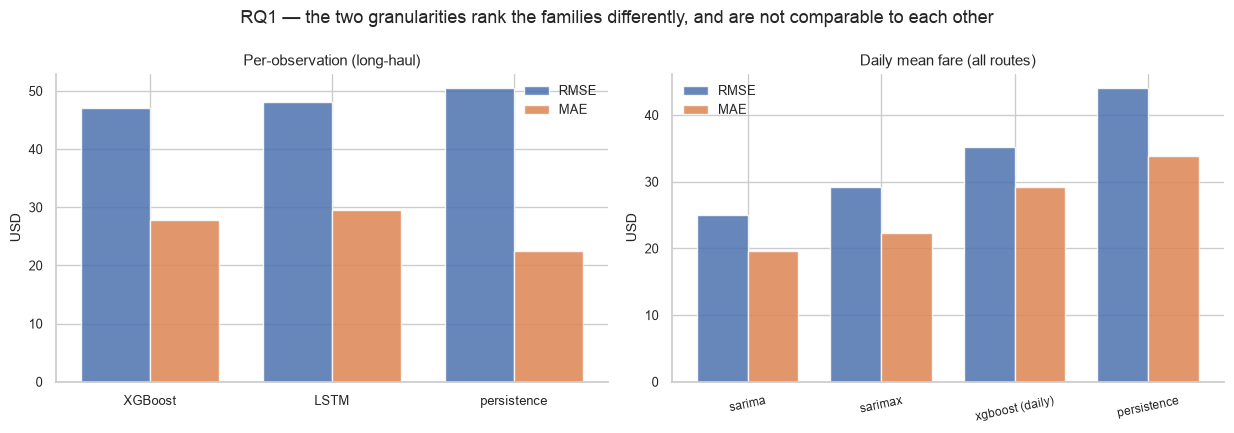

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

obs_models = ["XGBoost", "LSTM", "persistence"]
x = np.arange(len(obs_models)); w = 0.38
axes[0].bar(x - w/2, rq1_obs.loc["RMSE", obs_models], w, label="RMSE", color=PALETTE[0], alpha=0.85)
axes[0].bar(x + w/2, rq1_obs.loc["MAE", obs_models], w, label="MAE", color=PALETTE[1], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(obs_models)
axes[0].set_ylabel("USD"); axes[0].set_title("Per-observation (long-haul)")
axes[0].legend(frameon=False)

order = ["sarima", "sarimax", "xgboost (daily)", "persistence"]
means = daily.groupby("model")[["rmse", "mae"]].mean().loc[order]
x = np.arange(len(order))
axes[1].bar(x - w/2, means["rmse"], w, label="RMSE", color=PALETTE[0], alpha=0.85)
axes[1].bar(x + w/2, means["mae"], w, label="MAE", color=PALETTE[1], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=12, fontsize=8.5)
axes[1].set_ylabel("USD"); axes[1].set_title("Daily mean fare (all routes)")
axes[1].legend(frameon=False)

fig.suptitle("RQ1 — the two granularities rank the families differently, and are not comparable to each other")
fig.tight_layout()
save_fig(fig, "07_rq1_granularity")
plt.show()

## 2. Research question 2 — can a spike be predicted before it happens?

Yes, but modestly. All configurations are compared at per-observation granularity, long-haul.

In [9]:
CLF_METRICS = ["precision", "recall", "f1", "roc_auc", "avg_precision"]
rq2 = pd.DataFrame({
    "XGB unweighted": xgb_clf[xgb_clf.model == "unweighted"][CLF_METRICS].mean(),
    "XGB weighted": xgb_clf[xgb_clf.model == "weighted"][CLF_METRICS].mean(),
    "XGB wtd+tuned": xgb_clf[xgb_clf.model == "weighted + tuned threshold"][CLF_METRICS].mean(),
    "LSTM": lstm[(lstm.task == "classification") & (lstm.route_type == "long-haul")][CLF_METRICS].mean(),
    "base rate": xgb_clf[xgb_clf.model == "base rate"][CLF_METRICS].mean(),
}).round(3)
rq2

,XGB unweighted,XGB weighted,XGB wtd+tuned,LSTM,base rate
precision,0.707,0.235,0.420,0.161,0.000
recall,0.255,0.690,0.375,0.754,0.000
f1,0.374,0.350,0.377,0.265,0.000
roc_auc,0.864,0.860,0.825,0.824,0.500
avg_precision,0.460,0.447,0.370,0.344,0.066


In [10]:
lstm_f1 = fold_scores(lstm, "f1", task="classification", route_type="long-haul")
clf_tests = [
    paired_comparison(fold_scores(xgb_clf, "f1", model="weighted"), lstm_f1, "f1", "XGB weighted", "LSTM"),
    paired_comparison(fold_scores(xgb_clf, "roc_auc", model="weighted"),
                      fold_scores(lstm, "roc_auc", task="classification", route_type="long-haul"),
                      "roc_auc", "XGB weighted", "LSTM"),
    paired_comparison(fold_scores(xgb_clf, "f1", model="unweighted"),
                      fold_scores(xgb_clf, "f1", model="weighted"), "f1", "XGB unweighted", "XGB weighted"),
    paired_comparison(fold_scores(xgb_clf, "f1", model="weighted + tuned threshold"),
                      fold_scores(xgb_clf, "f1", model="unweighted"), "f1", "XGB wtd+tuned", "XGB unweighted"),
    paired_comparison(fold_scores(xgb_clf, "f1", model="unweighted"), lstm_f1, "f1", "XGB unweighted", "LSTM"),
]
comparison_table(clf_tests)

,metric,model A,model B,mean A,mean B,difference,A wins,sd of diffs,p,better,verdict
0,f1,XGB unweighted,LSTM,0.3739,0.2649,0.1090,5/5,0.0186,0.0002,XGB unweighted,distinguishable
1,f1,XGB weighted,LSTM,0.3500,0.2649,0.0851,5/5,0.0257,0.0018,XGB weighted,distinguishable
2,roc_auc,XGB weighted,LSTM,0.8599,0.8243,0.0356,5/5,0.0118,0.0025,XGB weighted,distinguishable
3,f1,XGB unweighted,XGB weighted,0.3739,0.3500,0.0239,4/5,0.0305,0.1541,—,within fold noise
4,f1,XGB wtd+tuned,XGB unweighted,0.3767,0.3739,0.0028,3/5,0.0421,0.8891,—,within fold noise


The test separates what matters from what does not, and the pattern is consistent:

**Between families it fires.** XGBoost beats the LSTM on F1 and on ROC AUC, in every fold.

**Between configurations of the same model it does not.** Unweighted, weighted and
threshold-tuned XGBoost are not distinguishable from one another on F1. What class weighting
changes is the *operating point* — precision 0.71 at recall 0.26 unweighted, inverting to 0.24
and 0.69 weighted — not the quality of the model. That is a decision about which error the
application can afford, and section 4 treats it as one.

**Against the base rate every model is clearly ahead.** A classifier predicting the base rate
scores F1 0.000 and ROC AUC 0.500 while being over 90% *accurate*, which is the concrete
reason accuracy was excluded from the metric set at the outset.

An F1 of about 0.35 is modest, and should be reported as such. The honest answer to research
question 2 is that spikes are predictable **well above chance but not reliably**: ROC AUC 0.86
means the ranking is genuinely informative, while precision of 0.24 at useful recall means most
warnings would be false alarms.

## 3. Every comparison, and which survive

The complete set, so that the failures are as visible as the successes.

In [11]:
all_tests = comparison_table(obs_tests + pooled_tests + daily_tests + clf_tests)
survived = (all_tests.verdict == "distinguishable").sum()
print(f"{survived} of {len(all_tests)} comparisons are distinguishable at 5% "
      f"({len(all_tests) - survived} fall within fold noise)\n")
all_tests

10 of 19 comparisons are distinguishable at 5% (9 fall within fold noise)



,metric,model A,model B,mean A,mean B,difference,A wins,sd of diffs,p,better,verdict
0,rmse,SARIMA,persistence,25.0640,43.9963,-18.9323,18/20,16.1539,0.0000,SARIMA,distinguishable
1,mae,SARIMA,persistence,19.6143,33.8345,-14.2202,18/20,12.3959,0.0001,SARIMA,distinguishable
2,f1,XGB unweighted,LSTM,0.3739,0.2649,0.1090,5/5,0.0186,0.0002,XGB unweighted,distinguishable
3,f1,XGB weighted,LSTM,0.3500,0.2649,0.0851,5/5,0.0257,0.0018,XGB weighted,distinguishable
4,roc_auc,XGB weighted,LSTM,0.8599,0.8243,0.0356,5/5,0.0118,0.0025,XGB weighted,distinguishable
5,rmse,XGBoost (both routes),persistence (both routes),34.4127,38.4389,-4.0262,9/10,3.8477,0.0091,XGBoost (both routes),distinguishable
6,rmse,SARIMA,xgboost (daily),25.0640,35.2435,-10.1794,15/20,17.1154,0.0155,SARIMA,distinguishable
7,mae,SARIMA,xgboost (daily),19.6143,29.2368,-9.6225,17/20,16.9456,0.0200,SARIMA,distinguishable
8,mae,LSTM,persistence,29.6142,22.4635,7.1507,0/5,4.3765,0.0217,persistence,distinguishable
9,mae,XGBoost (both routes),persistence (both routes),19.7474,16.2348,3.5127,0/10,4.7903,0.0456,persistence (both routes),distinguishable


/Users/sushansunuwar/LondonMet/flight-price-dissertation/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


saved -> reports/figures/07_significance.png


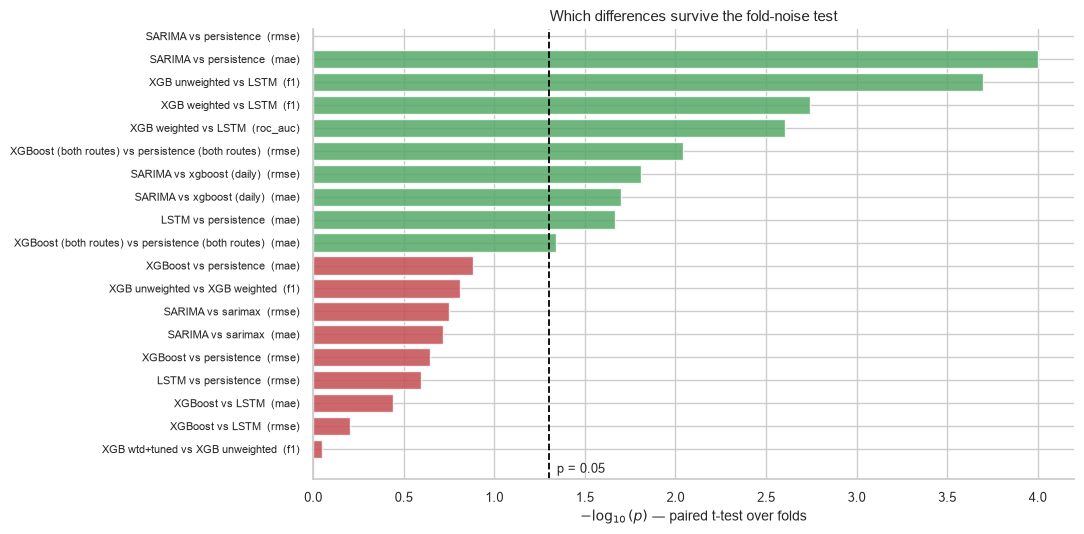

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.5))

table = all_tests.copy()
labels = [f"{r['model A']} vs {r['model B']}  ({r['metric']})" for _, r in table.iterrows()]
colours = [PALETTE[2] if v == "distinguishable" else PALETTE[3] for v in table.verdict]
y = np.arange(len(table))

ax.barh(y, -np.log10(table["p"].fillna(1.0)), color=colours, alpha=0.85)
ax.axvline(-np.log10(0.05), ls="--", lw=1.3, color="black")
ax.text(-np.log10(0.05), len(table) - 0.4, "  p = 0.05", fontsize=9, va="top")
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("$-\\log_{10}(p)$ — paired t-test over folds")
ax.set_title("Which differences survive the fold-noise test")
ax.invert_yaxis()

fig.tight_layout()
save_fig(fig, "07_significance")
plt.show()

## 4. Commercial appraisal

Research question 2 asks which model predicts spikes best; a product has to answer a different
question — **which operating point costs least**. The two errors are not symmetric:

- A **missed spike** leaves the traveller unwarned, and they pay the higher fare.
- A **false alarm** tells them to book when they need not have, and they may forgo a later
  saving.

Absolute currency values are avoided deliberately, because they depend on the product rather
than the data. What matters is the **ratio** between the two costs, and sweeping it shows both
which configuration a product should choose and where that choice changes.

Confusion counts are recovered exactly from the reported precision, recall and class counts.

In [13]:
# Rebuild the raw counts of each kind of mistake, so costs can be weighed.
#
# The model notebooks saved scores, not individual predictions, so the counts
# are reconstructed from precision and recall. This is exact arithmetic, not
# an estimate -- see confusion_from_metrics for the rearrangement.
#
# The two columns added at the end are the ones to quote in a presentation:
# what share of real spikes each setting missed, and how many false alarms it
# raised for every spike it actually caught.
configs = {
    "XGB unweighted": xgb_clf[xgb_clf.model == "unweighted"],
    "XGB weighted": xgb_clf[xgb_clf.model == "weighted"],
    "XGB wtd+tuned": xgb_clf[xgb_clf.model == "weighted + tuned threshold"],
    "LSTM": lstm[(lstm.task == "classification") & (lstm.route_type == "long-haul")],
}

confusions = {}
for name, frame in configs.items():
    totals = {"TP": 0.0, "FP": 0.0, "FN": 0.0, "TN": 0.0}
    for _, row in frame.iterrows():
        cm = confusion_from_metrics(row.precision, row.recall, row.n_positive, row.n_test)
        for key in totals:
            totals[key] += cm[key]
    confusions[name] = totals

confusion_table = pd.DataFrame(confusions).T.round(0).astype(int)
confusion_table["missed spikes %"] = (confusion_table.FN /
                                      (confusion_table.TP + confusion_table.FN) * 100).round(1)
confusion_table["false alarms per catch"] = (confusion_table.FP /
                                             confusion_table.TP.clip(lower=1)).round(2)
confusion_table

,TP,FP,FN,TN,missed spikes %,false alarms per catch
XGB unweighted,7056,2860,20363,392508,74.3,0.41
XGB weighted,19164,62344,8255,333024,30.1,3.25
XGB wtd+tuned,10257,17898,17162,377470,62.6,1.74
LSTM,20822,108536,6597,286832,24.1,5.21


In [14]:
# THE COMMERCIAL ARGUMENT. This cell produces the project's headline finding.
#
# The question it answers is not 'which model scores best' but 'which model
# would cost a business least'. Those are different questions and they have
# different answers.
#
# We do not invent pound values, because we have no basis for them. Instead we
# sweep the RATIO between the two mistakes -- 'what if missing a spike is
# twice as bad as a false alarm? ten times? fifty?' -- and record which model
# is cheapest at each point. 'switches' finds where the winner changes hands.
#
# The result: three bands, changing at 5x and 28x. Above 28x the LSTM wins,
# despite having lost every statistical comparison in this notebook, because
# it catches the most spikes. Being statistically best and being commercially
# right are not the same thing.
ratios = np.arange(1, 51)
costs = pd.DataFrame(
    {name: [expected_cost(cm, r) for r in ratios] for name, cm in confusions.items()},
    index=ratios,
)
cheapest = costs.idxmin(axis=1)

switches = [(int(ratios[i]), cheapest.iloc[i - 1], cheapest.iloc[i])
            for i in range(1, len(ratios)) if cheapest.iloc[i] != cheapest.iloc[i - 1]]
print("Cheapest configuration by cost ratio:")
for name in costs.columns:
    band = ratios[cheapest.to_numpy() == name]
    if len(band):
        print(f"  {name:<16} optimal when a missed spike costs {band.min()}–{band.max()}x a false alarm")
print("\nswitch points:", switches or "none")

Cheapest configuration by cost ratio:
  XGB unweighted   optimal when a missed spike costs 1–4x a false alarm
  XGB weighted     optimal when a missed spike costs 5–27x a false alarm
  LSTM             optimal when a missed spike costs 28–50x a false alarm

switch points: [(5, 'XGB unweighted', 'XGB weighted'), (28, 'XGB weighted', 'LSTM')]


saved -> reports/figures/07_commercial.png


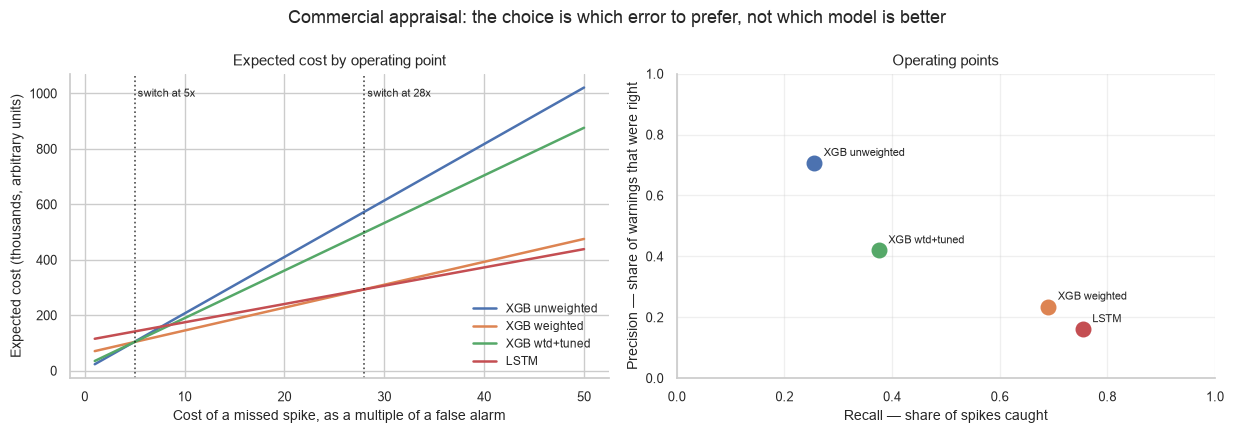

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

for i, name in enumerate(costs.columns):
    axes[0].plot(costs.index, costs[name] / 1e3, lw=1.8, label=name, color=PALETTE[i % len(PALETTE)])
for ratio, _, _ in switches:
    axes[0].axvline(ratio, ls=":", lw=1.2, color="black", alpha=0.7)
    axes[0].text(ratio, axes[0].get_ylim()[1] * 0.95, f" switch at {ratio}x", fontsize=8, va="top")
axes[0].set_xlabel("Cost of a missed spike, as a multiple of a false alarm")
axes[0].set_ylabel("Expected cost (thousands, arbitrary units)")
axes[0].set_title("Expected cost by operating point")
axes[0].legend(frameon=False, fontsize=8.5)

for i, name in enumerate(configs):
    row = rq2[name] if name in rq2.columns else None
    if row is not None:
        axes[1].scatter(row["recall"], row["precision"], s=110,
                        color=PALETTE[i % len(PALETTE)], zorder=3, label=name)
        axes[1].annotate(name, (row["recall"], row["precision"]),
                         textcoords="offset points", xytext=(7, 5), fontsize=8)
axes[1].set_xlabel("Recall — share of spikes caught")
axes[1].set_ylabel("Precision — share of warnings that were right")
axes[1].set_title("Operating points")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

fig.suptitle("Commercial appraisal: the choice is which error to prefer, not which model is better")
fig.tight_layout()
save_fig(fig, "07_commercial")
plt.show()

The appraisal reframes the classification result. The configurations were statistically
indistinguishable on F1, but they are **not** interchangeable commercially: they occupy
different points on the precision/recall curve, and which one a product should deploy depends
entirely on the cost ratio it faces.

The sweep produces three regimes, with switch points at **5×** and **28×**:

- Below 5×, when the two errors are of similar weight, **unweighted XGBoost** is cheapest — it
  warns rarely and is right 71% of the time.
- Between 5× and 27×, **weighted XGBoost** wins, catching 69% of spikes at 24% precision.
- Above 28×, the **LSTM** becomes cheapest, on the strength of the highest recall of any model
  (0.75).

That last regime is worth dwelling on. The LSTM lost every statistical comparison in section 2
— decisively, on F1 and ROC AUC, in every fold. It is nonetheless the right deployment choice
when a missed surge is very costly, because it catches the most spikes. **Statistical
superiority and commercial fitness are different properties, and this project measures both
separately rather than assuming the first implies the second.**

For a fare-alert product a missed surge plausibly costs somewhere in the 5–30× band — the
traveller pays a materially higher fare, while a false alarm costs them an option they may not
have taken — which places the weighted configuration as the reasonable default. The
justification is commercial, and rests on the sweep rather than on the metric table.

This is worth stating plainly in the discussion: **F1 is the wrong criterion for the deployment
decision**, even though it is the right one for comparing models. It weights the two errors
equally, and no real application does.

## 5. Research question 3 — which factors matter, and does it differ by route?

Feature importances are averaged over folds; single-fold rankings are unstable, particularly
among correlated features.

In [16]:
rq3 = importance.copy()
rq3.columns = [c.strip() for c in rq3.columns]
rq3 = rq3.sort_values("long-haul", ascending=False)
top = rq3.head(12).round(2)
top

,long-haul,short-haul,difference
rollStd,10.72,8.39,-2.33
seatsRemainingLag1,7.27,4.93,-2.34
zLag1,6.47,7.93,1.46
isBasicEconomy,5.06,9.00,3.95
daysBeforeDeparture,4.84,8.52,3.68
weekOfYear,4.51,3.41,-1.10
month,4.32,2.75,-1.57
isNonStop,4.23,4.01,-0.22
rollStdRatio,3.66,3.21,-0.45
airline,3.58,3.29,-0.30


In [17]:
named = ["daysBeforeDeparture", "dayOfWeek", "departureHour", "daysToNearestHoliday",
         "isSummerSeason", "isWeekend", "airline", "isNonStop", "isBasicEconomy"]
present = [f for f in named if f in rq3.index]
rq3.loc[present].round(2)

,long-haul,short-haul,difference
daysBeforeDeparture,4.84,8.52,3.68
dayOfWeek,1.52,1.92,0.40
departureHour,1.16,0.94,-0.22
daysToNearestHoliday,2.22,2.22,-0.01
isSummerSeason,3.33,2.67,-0.66
isWeekend,1.34,2.61,1.27
airline,3.58,3.29,-0.30
isNonStop,4.23,4.01,-0.22
isBasicEconomy,5.06,9.00,3.95


Research question 3 asks which factors matter most and whether that differs between route
types. Both parts have an answer, and one of them is negative.

**Booking horizon dominates, and it is route-dependent.** `daysBeforeDeparture` is worth
substantially more on the short-haul routes than the long-haul ones — consistent with the
booking curves measured in notebook 02, where short-haul fares rise about 65% into departure
while long-haul fares stay almost flat.

**Day of week matters less than the early evidence suggested.** Notebook 01 found lag-7
autocorrelation of 0.75 on short-haul against lag-1 of 0.46, and predicted day of week would
carry materially more weight there. It does carry more, but the margin is small. The
autocorrelation described fare *levels*; it does not transfer automatically to the timing of a
jump.

**`isWeekend` and `isSummerSeason` contribute essentially nothing.** The first is redundant
with `dayOfWeek`, which a tree can split directly. The second suggests season drives the fare
*level* rather than the timing of a spike — which is a meaningful negative result for a project
whose title includes seasonal demand, and should be reported rather than quietly dropped.

**Holidays cannot be answered properly with this data.** Only four federal holidays fall inside
the observation window, so a model forecasting the fourth has seen at most three. Notebook 05
demonstrated the consequence directly: the only test window containing a holiday was the only
one where SARIMAX degraded, by 47.9 RMSE on JFK–LAX. The honest conclusion is that the window
is too short to estimate a holiday effect, not that holidays do not matter.

## 6. Verdict

**RQ1 — how well can fares be predicted?** Well, but the winner depends on the target.
Per-observation, XGBoost and the LSTM are indistinguishable, and both beat persistence on RMSE
while *losing* to it on MAE. On the daily series SARIMA wins clearly. No single model family is
best, and any ranking that omits the target and its sample size is misleading.

**RQ2 — can a spike be predicted before it happens?** Yes, above chance but not reliably.
ROC AUC ≈ 0.86 with F1 ≈ 0.35. XGBoost beats the LSTM — the clearest result in the project —
but its own configurations cannot be separated from one another. At a useful recall most
warnings are false alarms, which bounds what could be claimed for a product built on this.

**RQ3 — which factors matter?** Booking horizon most, and roughly twice as much on short-haul.
Day of week matters more on short-haul but less than the autocorrelation implied. `isWeekend`
and `isSummerSeason` contribute nothing to spike timing. Holiday effects are not estimable from
four holidays.

## 7. Limitations

Stated as constraints on what the results support, not as caveats appended for form.

1. **The spike definition partly measures fare-bucket transitions.** Fares repeat exactly 62%
   of the time, so the rolling standard deviation collapses inside a flat run and any bucket
   change clears 2σ regardless of economic size. The definition was adapted from a commodities
   paper whose series do not behave this way.
2. **The observation window is too short for holidays**, and misses Thanksgiving by five days.
   Seasonal claims are limited to summer and four federal holidays.
3. **Late departures are right-censored** and are excluded. Spike rates would otherwise be
   biased downward, since the excluded flights were never observed in the window where spikes
   concentrate.
4. **Five folds give the significance test little power.** "Within fold noise" means a
   difference was not shown, never that models are equivalent.
5. **The feature set is not neutral between families.** It was designed for trees; the LSTM
   required clipping because time-index features extrapolate under rolling-origin validation.
6. **No model was tuned.** All three run at sensible defaults, which is the fair basis for
   comparing families but understates what any one could achieve.
7. **Results are specific to two US route pairs over six months**, and should not be read as
   general claims about airline pricing.

In [18]:
verdict = pd.DataFrame([
    {"question": "RQ1 per-observation", "best": "XGBoost = LSTM (not separable)",
     "evidence": "RMSE 47.0 vs 48.1, p > 0.05"},
    {"question": "RQ1 daily series", "best": "SARIMA",
     "evidence": "median RMSE 19.4 vs 29.9, p < 0.05 over 20 cells"},
    {"question": "RQ1 vs naive", "best": "split decision",
     "evidence": "XGBoost wins RMSE, persistence wins MAE, 10/10 folds"},
    {"question": "RQ2 best family", "best": "XGBoost",
     "evidence": "F1 0.350 vs 0.265, 5/5 folds, p < 0.01"},
    {"question": "RQ2 best configuration", "best": "not separable",
     "evidence": "F1 0.350 / 0.374 / 0.377, all p > 0.05"},
    {"question": "RQ2 deployment choice", "best": "depends on cost ratio",
     "evidence": "unweighted cheapest below 5x, weighted 5-27x, LSTM above 28x"},
    {"question": "RQ3 strongest factor", "best": "daysBeforeDeparture",
     "evidence": "~2x more important on short-haul"},
    {"question": "RQ3 holidays", "best": "not estimable",
     "evidence": "4 holidays in window; SARIMAX degrades on the only holiday fold"},
]).set_index("question")

verdict.to_csv(RESULTS / "07_verdict.csv")
all_tests.to_csv(RESULTS / "07_significance_tests.csv", index=False)
print(f"wrote 07_verdict.csv and 07_significance_tests.csv ({len(all_tests)} tests)")
verdict

wrote 07_verdict.csv and 07_significance_tests.csv (19 tests)


,best,evidence
question,,
RQ1 per-observation,XGBoost = LSTM (not separable),"RMSE 47.0 vs 48.1, p > 0.05"
RQ1 daily series,SARIMA,"median RMSE 19.4 vs 29.9, p < 0.05 over 20 cells"
RQ1 vs naive,split decision,"XGBoost wins RMSE, persistence wins MAE, 10/10..."
RQ2 best family,XGBoost,"F1 0.350 vs 0.265, 5/5 folds, p < 0.01"
RQ2 best configuration,not separable,"F1 0.350 / 0.374 / 0.377, all p > 0.05"
RQ2 deployment choice,depends on cost ratio,"unweighted cheapest below 5x, weighted 5-27x, ..."
RQ3 strongest factor,daysBeforeDeparture,~2x more important on short-haul
RQ3 holidays,not estimable,4 holidays in window; SARIMAX degrades on the ...
